# SETUP FIREDRAKE SIMULATION 
We will treat F and Q, not as known functions but as calculated values on the same grid as our solver, below. Meaning every time step the solver will make a call to F and Q to solve for the next timestep value. This is a useful holder for calls to external models of chemistry and radiation will will compute updated values of Q and F through time. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from firedrake import *

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


# load your ERA 5 T data 

T shape: (22,)
Z shape: (22,)
Z range: 5.9 to 47.8 km
T range: 193.7 to 267.9 K


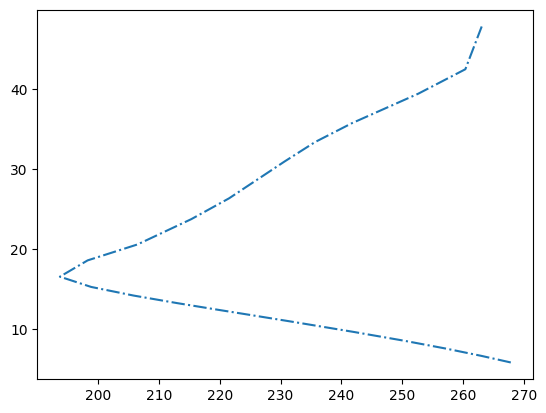

In [2]:
test=xr.open_dataset('../ERA5_T_data/data_0.nc')
T=test.t.mean('latitude').mean('longitude').mean('valid_time')
Z=test.z.mean('latitude').mean('longitude').mean('valid_time')/9.81
plt.figure()
plt.plot(T.data,Z.data/1000,'-.',label='ERA5')


print(f'T shape: {T.data.shape}')
print(f'Z shape: {Z.data.shape}')
print(f'Z range: {Z.data.min()/1000:.1f} to {Z.data.max()/1000:.1f} km')
print(f'T range: {T.data.min():.1f} to {T.data.max():.1f} K')

## define out calls for F and Q 

### Constants for these functions must be named OUTSIdE firedrake 

In [3]:
a_val = 6371e3 # m 
H_val = 7e3 # m
R_val = 287 # J/(kg K)
Cp_val = 1005
g_val = 9.81
omega_e_val= 7.29e-5
S0_val = 3e-3 + g_val/Cp_val  #is this correct? just considering this linear? 

# QBO Parameters:  
#dtheta = L / a 
dtheta=(10*np.pi)/180 # radians latitude 
QBO_f=0.1/24/3600 # m s-1 s-1 
QBO_dz=6*1000# m 
QBO_z0=30*1000 # m 
m=-(2*np.pi)/(25*1000) #m -1 
QBO_T=840*3600*24 # days - cycle time for QBO  this is a constant 
QBO_omega=(np.pi*2)/QBO_T # per second [s-1] - this is a constant 
L_val = 1100e3
alpha = 1.0 / (40.0 * 86400.0) # radiative damping rate, 1/40 days^-1 in s^-1

In [4]:
global a_val, H_val, R_val, Cp_val, g_val, omega_e_val, S0_val, dtheta, QBO_f, QBO_dz, QBO_z0, m, QBO_T, QBO_omega, L_val, alpha

In [5]:

def F(lat,z,t): # Setup F as a 3D matrix z, lat, time 
    # Saving matrix for F (idealized wave forcing)
    F=np.zeros([len(z),len(lat),1])
    for i in np.arange(0,len(lat)): 
        for j in np.arange(0,len(z)):
            theta_val=(lat[i]*np.pi)/180 #convert to radians
            beta_val=2*omega_e_val*np.cos(theta_val)/a_val
            #kk = 2*R_val/(H_val*L_val*L_val*beta_val)
            F[j,i,0]=QBO_f*np.exp(-1*theta_val**2/(2*dtheta**2))*np.exp(-1*(z[j]-QBO_z0)**2/(2*QBO_dz**2))*np.cos((m*z[j]-QBO_omega*t))
    return F

In [6]:
def Q(lat, z, t, T):
    # Simple test case: Newtonian cooling with alpha = 1/40 days^-1.
    return -alpha * T

# TRYING OUT NEW VERSION 

## Setup Grid 

In [26]:
# Define your grid : 
z0 = 5000
z1 = 50000
dz = 100
z=np.arange(z0,z1,dz) # ALTITUDE IN METERS

# latitude  
lat0=-20
lat1=21
dlat=0.5
lat = np.arange(lat0,lat1,dlat) # LATITUDE IN DEGREE

# Start & end time (no. QBO periods)
t0=0
dt=0.3*3600*24 #s 
t1=840*2*3600*24 #s  Two cycles of QBO 
times=np.arange(t0,t1,dt)


## generate your S0 term 

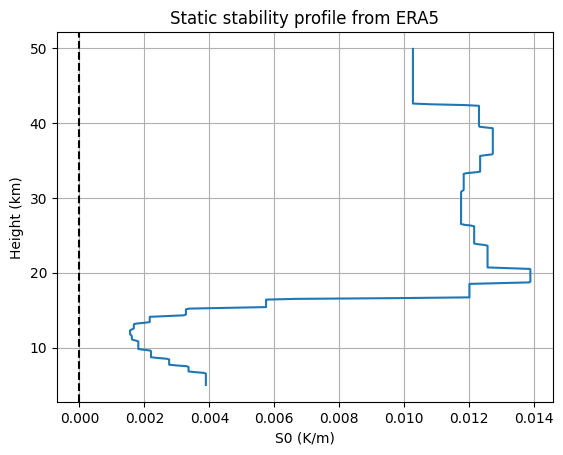

S0 range: 1.558e-03 to 1.388e-02 K/m


In [8]:
from scipy.interpolate import interp1d

# ERA5 data
T_era5 = T.data        # (22,) in K
Z_era5 = Z.data        # (22,) in m

# ── 1. Interpolate T onto your model z grid ───────────────────────────────────
T_interp_func = interp1d(Z_era5, T_era5, kind='linear', fill_value='extrapolate')
T_on_z = T_interp_func(z)   # (nz,) — T at each model level

# ── 2. Compute dT/dz numerically ─────────────────────────────────────────────
dTdz = np.gradient(T_on_z, z)   # (nz,) K/m

# ── 3. Build S0(z) ────────────────────────────────────────────────────────────
S0_profile = dTdz + g_val/Cp_val   # (nz,) K/m

# ── 4. Quick sanity check ─────────────────────────────────────────────────────
plt.figure()
plt.plot(S0_profile, z/1000)
plt.xlabel('S0 (K/m)')
plt.ylabel('Height (km)')
plt.title('Static stability profile from ERA5')
plt.axvline(0, color='k', linestyle='--')
plt.grid()
plt.show()

print(f'S0 range: {S0_profile.min():.3e} to {S0_profile.max():.3e} K/m')

# NEW FINAL VERSION OF FIREDRAKE #


In [27]:
# ── Reference scales ──────────────────────────────────────────────────────────
beta0 = 2 * 7.29e-5 / 6.371e6                        # beta at equator (1/m/s)
N0    = np.sqrt(np.mean(R_val/H_val * S0_profile))    # mean N (s⁻¹)
y0    = 10 * np.pi/180 * 6.371e6                      # 10° in metres
Z_ref = H_val                                          # 7000 m
Y_ref = (N0 * Z_ref) / (beta0 * y0)                  # ~5566 km

print(f'Y_ref = {Y_ref/1e3:.0f} km,  Z_ref = {Z_ref/1e3:.0f} km')

# ── 1. Non-dimensional grid extents ───────────────────────────────────────────
lat_m_min = lat0 * np.pi/180 * 6.371e6
lat_m_max = lat1 * np.pi/180 * 6.371e6

y_nd_min = lat_m_min / Y_ref
y_nd_max = lat_m_max / Y_ref
z_nd_min = z0 / Z_ref
z_nd_max = z1 / Z_ref

print(f'y_nd range: {y_nd_min:.4f} to {y_nd_max:.4f}')
print(f'z_nd range: {z_nd_min:.4f} to {z_nd_max:.4f}')

# ── 2. Mesh in non-dimensional coordinates ────────────────────────────────────
ny, nz = len(lat), len(z)
mesh = RectangleMesh(ny-1, nz-1,
                     y_nd_max - y_nd_min,
                     z_nd_max - z_nd_min)

x_nd, z_nd_raw = SpatialCoordinate(mesh)

# Shift to correct non-dimensional range
y_nd_coord = x_nd      + y_nd_min
z_nd_coord = z_nd_raw  + z_nd_min

# Physical coordinates
lat_coord_m   = y_nd_coord * Y_ref
z_coord_m     = z_nd_coord * Z_ref
lat_coord_deg = lat_coord_m / (np.pi/180 * 6.371e6)

# ── 3. Function space ─────────────────────────────────────────────────────────
V = FunctionSpace(mesh, "CG", 1)

# ── 4. Helper function ────────────────────────────────────────────────────────
def numpy_to_function(data_2d, func):
    """Load a (nz, nlat) numpy array onto a Firedrake Function using coordinate-based interpolation."""
    from scipy.interpolate import RegularGridInterpolator
    interp = RegularGridInterpolator(
        (z, lat),
        data_2d,
        method='linear',
        bounds_error=False,
        fill_value=0.0
    )
    coords  = mesh.coordinates.dat.data
    y_phys  = (coords[:, 0] + y_nd_min) * Y_ref / (np.pi/180 * 6.371e6)  # degrees
    z_phys  = (coords[:, 1] + z_nd_min) * Z_ref                            # metres
    node_coords = np.column_stack([z_phys, y_phys])
    func.dat.data[:] = interp(node_coords).squeeze()

# ── 5. Constants ──────────────────────────────────────────────────────────────
R       = Constant(287.0)
H       = Constant(7000.0)
Omega   = Constant(7.2921e-5)
R_earth = Constant(6.371e6)
Y_ref_c = Constant(Y_ref)
Z_ref_c = Constant(Z_ref)

# ── 6. S0 from ERA5 ───────────────────────────────────────────────────────────
S0_2d   = np.tile(S0_profile[:, np.newaxis], (1, ny))
S0_func = Function(V, name="S0")
numpy_to_function(S0_2d, S0_func)

# Floor S0 on the mesh: boundary nodes that fall outside the numpy grid convex
# hull get fill_value=0.0, which makes N2=0 and blows up the f²/N² term.
# Use half the minimum physical S0 value as a safe lower bound.
S0_floor = float(np.min(S0_profile) * 0.5)
S0_func.dat.data[:] = np.maximum(S0_func.dat.data, S0_floor)
print(f'S0 floor: {S0_floor:.3e}')
print(f'S0 on mesh min/max: {S0_func.dat.data.min():.3e} / {S0_func.dat.data.max():.3e}')

S0_np   = np.tile(S0_profile[:, np.newaxis], (1, ny))   # for numpy T update

# ── 7. Derived quantities ─────────────────────────────────────────────────────
beta = 2 * Omega / R_earth
N2   = R / H * S0_func

# ── 8. Source term Functions ──────────────────────────────────────────────────
F_func  = Function(V, name="F")
Q_func = Function(V, name="Q")

# ── 9. Variational problem ────────────────────────────────────────────────────
# Implements equation (6.7) from the notes on a non-dimensional mesh.
# Firedrake Dx differentiates with respect to X=y/Y_ref and Z=z/Z_ref,
# so the chain-rule factors below convert derivatives back to physical metres.
#
# Strong form (6.3):  β²y²·∂²ψ/∂z² + N²·∂²ψ/∂y² = βy·∂F/∂z + (R/H)·∂Q/∂y
# Weak form  (6.7):  ∫ β²y²·∂ϕ/∂z·∂ψ/∂z + N²·∂ϕ/∂y·∂ψ/∂y dV
#                  = -∫ ϕ·(βy·∂F/∂z + (R/H)·∂Q/∂y) dV
#
# Mesh axis 0 = X=y/Y_ref, axis 1 = Z=z/Z_ref.
# β²y² vanishes at equator — eq_scale brings matrix entries to O(1).
psi     = Function(V, name="psi")
psi_tri = TrialFunction(V)
v       = TestFunction(V)

# Scale factor after metric terms: typical coefficients are
# (βy0)²/Z_ref² and N²/Y_ref², both ~O(1e-17).
N2_ref       = float(R_val/H_val * np.mean(S0_profile))   # mean N² (s⁻²)
lhs_scale_val = max((beta0 * y0)**2 / Z_ref**2, N2_ref / Y_ref**2)
eq_scale_val = 1.0 / lhs_scale_val
eq_scale     = Constant(eq_scale_val)
print(f'N2_ref = {N2_ref:.3e},  lhs_scale = {lhs_scale_val:.3e},  eq_scale = {eq_scale_val:.3e}')

# Bilinear form — equation (6.8) from notes
a = eq_scale * ( beta**2 * lat_coord_m**2 * (1/Z_ref_c**2) * Dx(v, 1) * Dx(psi_tri, 1)
               + N2                        * (1/Y_ref_c**2) * Dx(v, 0) * Dx(psi_tri, 0)
               ) * dx

# RHS — equation (6.9) from notes
rhs_expr = eq_scale * (-v * ( beta * lat_coord_m * (1/Z_ref_c) * Dx(F_func, 1)
                              + (R / H)           * (1/Y_ref_c) * Dx(Q_func, 0)
                              )) * dx

# ── 10. Boundary conditions ───────────────────────────────────────────────────
# ψ = 0 at bottom and top (no overturning through those boundaries).
# No BC on north/south edges → natural Neumann (∂ψ/∂n = 0, i.e. w* = 0 there).
bc_bottom = DirichletBC(V, Constant(0), 1)
bc_top    = DirichletBC(V, Constant(0), 2)
#bcs = [bc_bottom, bc_top]
bcs=[bc_bottom, bc_top]

# ── 11. Pre-loop setup ────────────────────────────────────────────────────────
U_np      = np.zeros((nz, ny))
T_np      = np.zeros((nz, ny))
psi_store = np.zeros((len(times), nz, ny))
U_store   = np.zeros((len(times), nz, ny))
T_store   = np.zeros((len(times), nz, ny))
dt_val    = float(dt)

beta_np   = 2 * 7.2921e-5 / 6.371e6   # beta-plane value from section 6

# Regular grid for psi extraction — defined once outside the loop
ZZ, LL = np.meshgrid(z, lat, indexing='ij')   # both (nz, nlat)

# Pre-compute Firedrake DOF physical coordinates for psi extraction
coords     = mesh.coordinates.dat.data
y_phys_dof = (coords[:, 0] + y_nd_min) * Y_ref / (np.pi/180 * 6.371e6)  # degrees
z_phys_dof = (coords[:, 1] + z_nd_min) * Z_ref                           # metres

# Constant arrays used in time-stepping — defined once outside the loop
lat_m      = lat * np.pi/180 * 6.371e6              # (nlat,) metres
lattile_np = np.tile(lat_m[np.newaxis, :], (nz, 1)) # (nz, nlat) f = beta*y

# ── 12. Time loop ─────────────────────────────────────────────────────────────
# Store the initial state at t0, then update over [t_n, t_{n+1}] using midpoint fields.
psi_store[0] = 0.0
U_store[0]   = U_np
T_store[0]   = T_np

for k in range(1, len(times)):

    # --- Compute midpoint wave forcing and Q -----------------------------------
    t_mid = float(times[k - 1] + 0.5 * dt_val)
    F_np  = F(lat, z, t_mid)
    Q_np = Q(lat, z, t_mid, T_np)     # Q = -alpha*T, using the known T at t

    # --- Load into Firedrake and solve for midpoint psi ------------------------
    numpy_to_function(F_np.squeeze(), F_func)   # squeeze (nz,nlat,1) -> (nz,nlat)
    numpy_to_function(Q_np,           Q_func)
    solve(a == rhs_expr, psi, bcs=bcs,
          solver_parameters={"ksp_type": "preonly", "pc_type": "lu"})

    # --- Step-1 diagnostics to isolate NaN source ----------------------------
    if k == 1:
        print(f'  [k=1] psi.dat.data min/max: {psi.dat.data.min():.3e} / {psi.dat.data.max():.3e}')
        print(f'  [k=1] psi NaN: {np.isnan(psi.dat.data).any()}')
        print(f'  [k=1] F_func NaN: {np.isnan(F_func.dat.data).any()}')
        print(f'  [k=1] Q_func NaN: {np.isnan(Q_func.dat.data).any()}')
        print(f'  [k=1] F_np.squeeze() NaN: {np.isnan(F_np.squeeze()).any()}')
        print(f'  [k=1] Q_np NaN: {np.isnan(Q_np).any()}')

    # Safe extraction: interpolate psi from Firedrake DOFs onto regular (z, lat) grid
    # using physical coordinates (pre-computed outside loop).
    from scipy.interpolate import LinearNDInterpolator
    psi_vals   = psi.dat.data[:]
    interp_psi = LinearNDInterpolator(
        list(zip(z_phys_dof, y_phys_dof)), psi_vals, fill_value=0.0
    )
    psi_mid_np = interp_psi(ZZ, LL)   # (nz, nlat)

    if k == 1:
        print(f'  [k=1] psi_mid_np NaN: {np.isnan(psi_mid_np).any()}')
        print(f'  [k=1] psi_mid_np min/max: {np.nanmin(psi_mid_np):.3e} / {np.nanmax(psi_mid_np):.3e}')
        dpsi_dz_test = np.gradient(psi_mid_np, z, axis=0)
        dpsi_dy_test = np.gradient(psi_mid_np, lat_m, axis=1)
        print(f'  [k=1] dpsi_dz NaN: {np.isnan(dpsi_dz_test).any()}')
        print(f'  [k=1] dpsi_dy NaN: {np.isnan(dpsi_dy_test).any()}')
        U_test = U_np + dt_val * (F_np.squeeze() - beta_np * lattile_np * dpsi_dz_test)
        T_test = T_np + dt_val * (Q_np - S0_np * dpsi_dy_test)
        print(f'  [k=1] U_test NaN: {np.isnan(U_test).any()}')
        print(f'  [k=1] T_test NaN: {np.isnan(T_test).any()}')

    # --- Gradients of psi ----------------------------------------------------
    dpsi_dz = np.gradient(psi_mid_np, z,     axis=0)
    dpsi_dy = np.gradient(psi_mid_np, lat_m, axis=1)

    # --- Step U and T forward ------------------------------------------------
    U_np = U_np + dt_val * (F_np.squeeze() - beta_np * lattile_np * dpsi_dz)
    T_np = T_np + dt_val * (Q_np           - S0_np   * dpsi_dy)

    # --- Store ---------------------------------------------------------------
    psi_store[k] = psi_mid_np
    U_store[k]   = U_np
    T_store[k]   = T_np

    if k % 50 == 0:
        print(f'Step {k}/{len(times)},  t = {times[k]/86400:.0f} days,  '
              f'|ψ| = {abs(psi_mid_np).max():.3e},  '
              f'|U| = {abs(U_np).max():.3e},  '
              f'|T| = {abs(T_np).max():.3e},  '
              f'|Q| = {abs(Q_np).max():.3e}')
       
        # More informative diagnostic — evaluate at ~10° lat index
        iy10 = np.argmin(abs(lat - 10))   # index of 10° lat
        print(f'  |beta*y*dpsi_dz @ 10°| = {abs(beta_np * (10*np.pi/180*6.371e6) * dpsi_dz[:, iy10]).max():.3e}')
        print(f'  |F_np @ 10°|           = {abs(F_np[:, iy10]).max():.3e}')
        print(f'  ratio                  = {abs(beta_np * (10*np.pi/180*6.371e6) * dpsi_dz[:, iy10]).max() / abs(F_np[:, iy10]).max():.3e}')

# ── 13. Save to disk ──────────────────────────────────────────────────────────
np.save('psi_store.npy', psi_store)
np.save('U_store.npy',   U_store)
np.save('T_store.npy',   T_store)
print('Saved psi, U, T to disk.')

Y_ref = 5446 km,  Z_ref = 7 km
y_nd range: -0.4084 to 0.4288
z_nd range: 0.7143 to 7.1429
S0 floor: 7.789e-04
S0 on mesh min/max: 7.789e-04 / 1.388e-02
N2_ref = 3.920e-04,  eq_scale = 2.551e+03
  [k=1] psi.dat.data min/max: -1.077e-09 / 1.373e-09
  [k=1] psi NaN: False
  [k=1] F_func NaN: False
  [k=1] Q_func NaN: False
  [k=1] F_np.squeeze() NaN: False
  [k=1] Q_np NaN: False
  [k=1] psi_mid_np NaN: False
  [k=1] psi_mid_np min/max: -1.075e-09 / 1.371e-09
  [k=1] dpsi_dz NaN: False
  [k=1] dpsi_dy NaN: False
  [k=1] U_test NaN: False
  [k=1] T_test NaN: False
Step 50/5600,  t = 15 days,  |ψ| = 1.376e-09,  |U| = 1.150e+00,  |T| = 2.341e-11,  |Q| = 6.663e-18
  |beta*y*dpsi_dz @ 10°| = 3.786e-17
  |F_np @ 10°|           = 5.262e-07
  ratio                  = 7.196e-11
Step 100/5600,  t = 30 days,  |ψ| = 1.378e-09,  |U| = 2.243e+00,  |T| = 3.949e-11,  |Q| = 1.135e-17
  |beta*y*dpsi_dz @ 10°| = 3.717e-17
  |F_np @ 10°|           = 5.007e-07
  ratio                  = 7.424e-11
Step 150/560

Step 1850/5600,  t = 555 days,  |ψ| = 1.344e-09,  |U| = 2.327e+01,  |T| = 7.119e-11,  |Q| = 2.060e-17
  |beta*y*dpsi_dz @ 10°| = 2.044e-17
  |F_np @ 10°|           = 6.240e-07
  ratio                  = 3.275e-11
Step 1900/5600,  t = 570 days,  |ψ| = 1.331e-09,  |U| = 2.243e+01,  |T| = 7.079e-11,  |Q| = 2.049e-17
  |beta*y*dpsi_dz @ 10°| = 1.671e-17
  |F_np @ 10°|           = 6.419e-07
  ratio                  = 2.603e-11
Step 1950/5600,  t = 585 days,  |ψ| = 1.317e-09,  |U| = 2.150e+01,  |T| = 7.029e-11,  |Q| = 2.034e-17
  |beta*y*dpsi_dz @ 10°| = 1.301e-17
  |F_np @ 10°|           = 6.578e-07
  ratio                  = 1.977e-11
Step 2000/5600,  t = 600 days,  |ψ| = 1.300e-09,  |U| = 2.050e+01,  |T| = 6.970e-11,  |Q| = 2.017e-17
  |beta*y*dpsi_dz @ 10°| = 1.365e-17
  |F_np @ 10°|           = 6.714e-07
  ratio                  = 2.033e-11
Step 2050/5600,  t = 615 days,  |ψ| = 1.282e-09,  |U| = 1.942e+01,  |T| = 6.901e-11,  |Q| = 1.997e-17
  |beta*y*dpsi_dz @ 10°| = 1.413e-17
  |F_np @

Step 3800/5600,  t = 1140 days,  |ψ| = 1.261e-09,  |U| = 2.204e+01,  |T| = 6.320e-11,  |Q| = 1.828e-17
  |beta*y*dpsi_dz @ 10°| = 2.358e-17
  |F_np @ 10°|           = 6.884e-07
  ratio                  = 3.425e-11
Step 3850/5600,  t = 1155 days,  |ψ| = 1.281e-09,  |U| = 2.288e+01,  |T| = 6.464e-11,  |Q| = 1.870e-17
  |beta*y*dpsi_dz @ 10°| = 2.678e-17
  |F_np @ 10°|           = 6.787e-07
  ratio                  = 3.946e-11
Step 3900/5600,  t = 1170 days,  |ψ| = 1.298e-09,  |U| = 2.365e+01,  |T| = 6.549e-11,  |Q| = 1.894e-17
  |beta*y*dpsi_dz @ 10°| = 2.964e-17
  |F_np @ 10°|           = 6.665e-07
  ratio                  = 4.447e-11
Step 3950/5600,  t = 1185 days,  |ψ| = 1.313e-09,  |U| = 2.434e+01,  |T| = 6.658e-11,  |Q| = 1.926e-17
  |beta*y*dpsi_dz @ 10°| = 3.213e-17
  |F_np @ 10°|           = 6.520e-07
  ratio                  = 4.928e-11
Step 4000/5600,  t = 1200 days,  |ψ| = 1.327e-09,  |U| = 2.494e+01,  |T| = 6.755e-11,  |Q| = 1.954e-17
  |beta*y*dpsi_dz @ 10°| = 3.422e-17
  |F

# FORMATTING PLOTS 

In [28]:
# -- Plotting setup and time/latitude alignment --------------------------------
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# u and T are stored at t. F, v, and w are evaluated at t+dt/2.
#U_store = np.load("U_store.npy")   # (ntimes, nz, nlat), u at t
#T_store = np.load("T_store.npy")   # (ntimes, nz, nlat), T at t
#psi_store = np.load("psi_store.npy")

t = np.arange(t0, t1, dt)
t_days = t / 86400.0
t_plus_dt2 = t[:-1] + 0.5 * dt
t_plus_dt2_days = t_plus_dt2 / 86400.0
expected_shape = (len(t), nz, ny)

assert U_store.shape == expected_shape, f"U_store shape {U_store.shape} != {expected_shape}"
assert T_store.shape == expected_shape, f"T_store shape {T_store.shape} != {expected_shape}"
assert psi_store.shape == expected_shape, f"psi_store shape {psi_store.shape} != {expected_shape}"

# Latitude cuts used by all time-height plots.
target_lats = [0, 10, 15]
target_lat_indices = [int(np.argmin(np.abs(lat - target))) for target in target_lats]
for target, iy in zip(target_lats, target_lat_indices):
    print(f"Target latitude {target:g} deg -> using grid latitude {lat[iy]:g} deg (index {iy})")

LAT, Z_km = np.meshgrid(lat, z / 1000.0)

def symmetric_levels(data, n=41):
    vmax = float(np.nanmax(np.abs(data)))
    if not np.isfinite(vmax) or vmax == 0.0:
        vmax = 1.0
    return np.linspace(-vmax, vmax, n)

def nearest_time_index(day):
    return int(np.argmin(np.abs(t_days - day)))

def forcing_at_midpoint(k):
    return F(lat, z, float(t_plus_dt2[k])).squeeze()

def build_forcing_store():
    F_mid = np.empty((len(t_plus_dt2), nz, ny))
    for k in range(len(t_plus_dt2)):
        F_mid[k] = forcing_at_midpoint(k)
    return F_mid

F_store = build_forcing_store()

# From the notes: v = -dpsi/dz and w = dpsi/dy. With the metric factors above,
# psi has units m^2/s, so these physical-grid gradients give v and w in m/s.
psi_mid_store = psi_store[1:]
lat_m = lat * np.pi/180 * 6.371e6
v_store = -np.gradient(psi_mid_store, z, axis=1)
w_store =  np.gradient(psi_mid_store, lat_m, axis=2)

levels_F = symmetric_levels(F_store)
levels_v = symmetric_levels(v_store)
levels_w = symmetric_levels(w_store)
levels_U = symmetric_levels(U_store)
levels_T = symmetric_levels(T_store)

print("u and T are plotted at t.")
print("F, v, and w are plotted at t+dt/2.")


Target latitude 0 deg -> using grid latitude 0 deg (index 40)
Target latitude 10 deg -> using grid latitude 10 deg (index 60)
Target latitude 15 deg -> using grid latitude 15 deg (index 70)
u and T are plotted at t.
F, v, and w are plotted at t+dt/2.


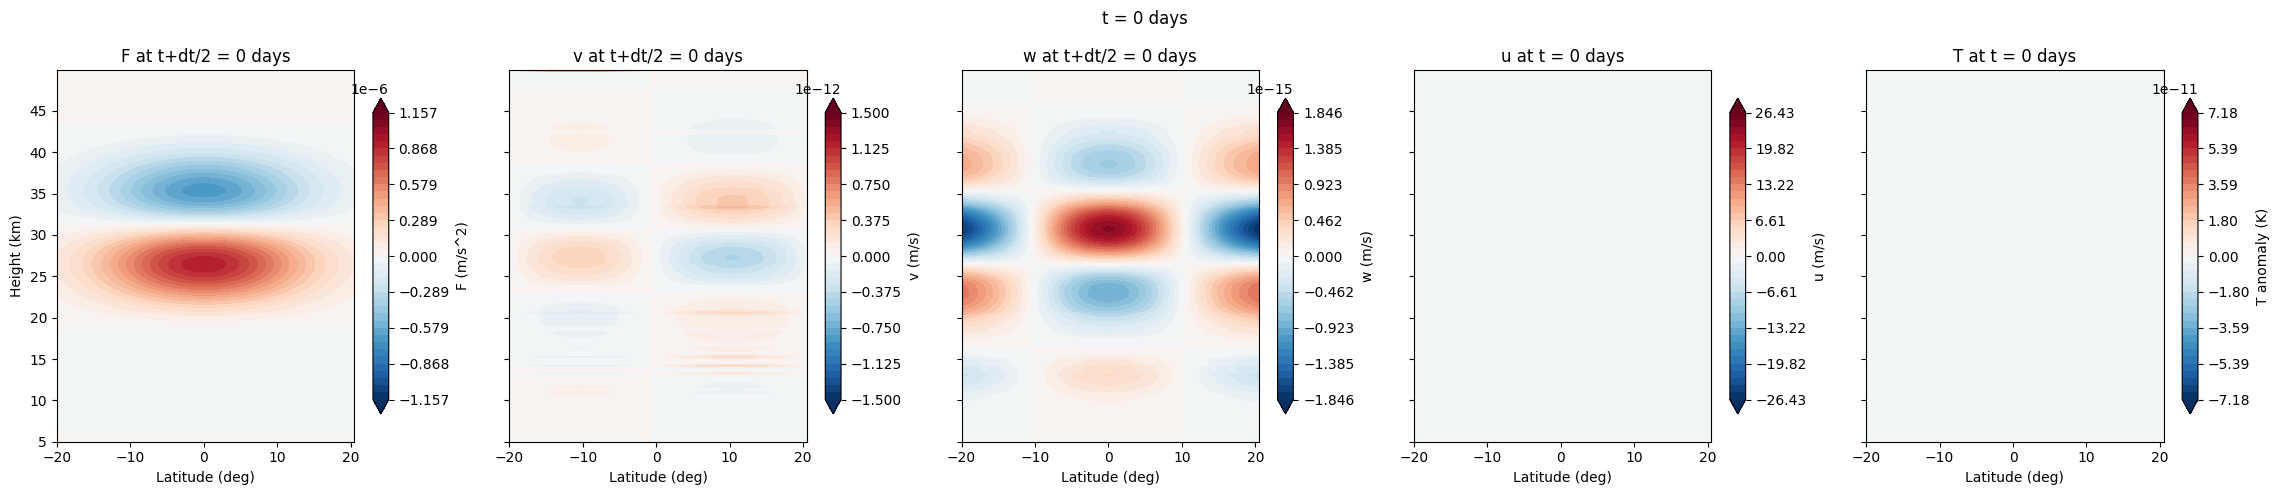

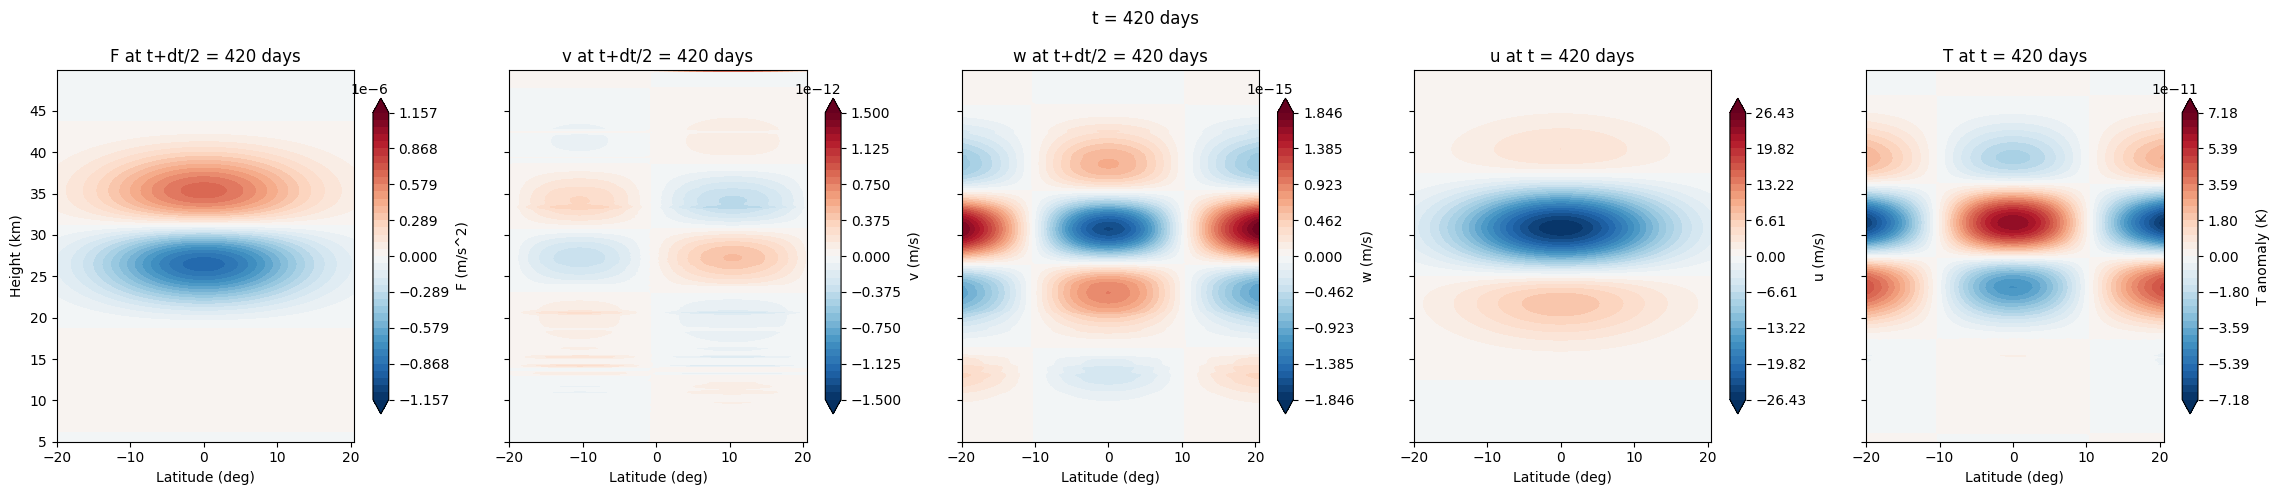

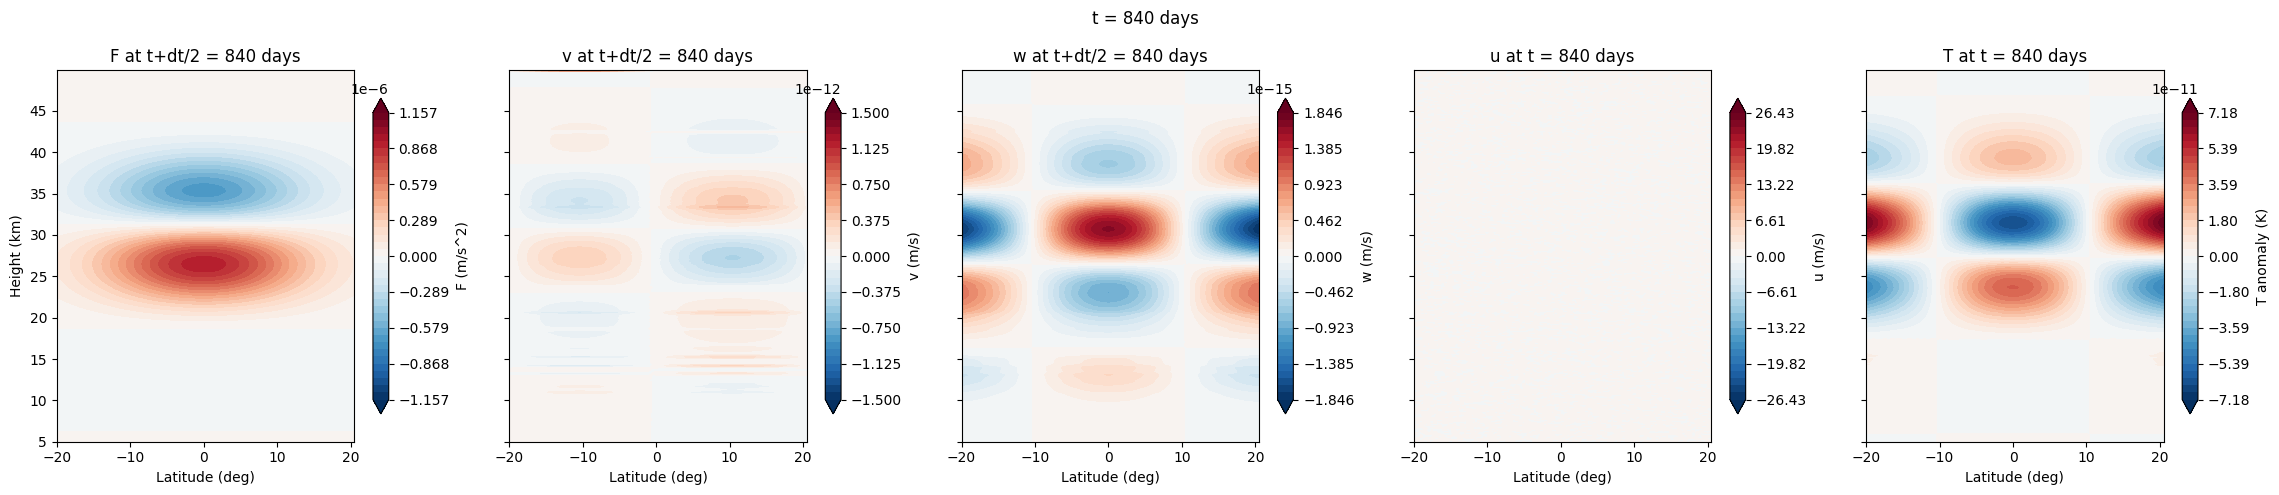

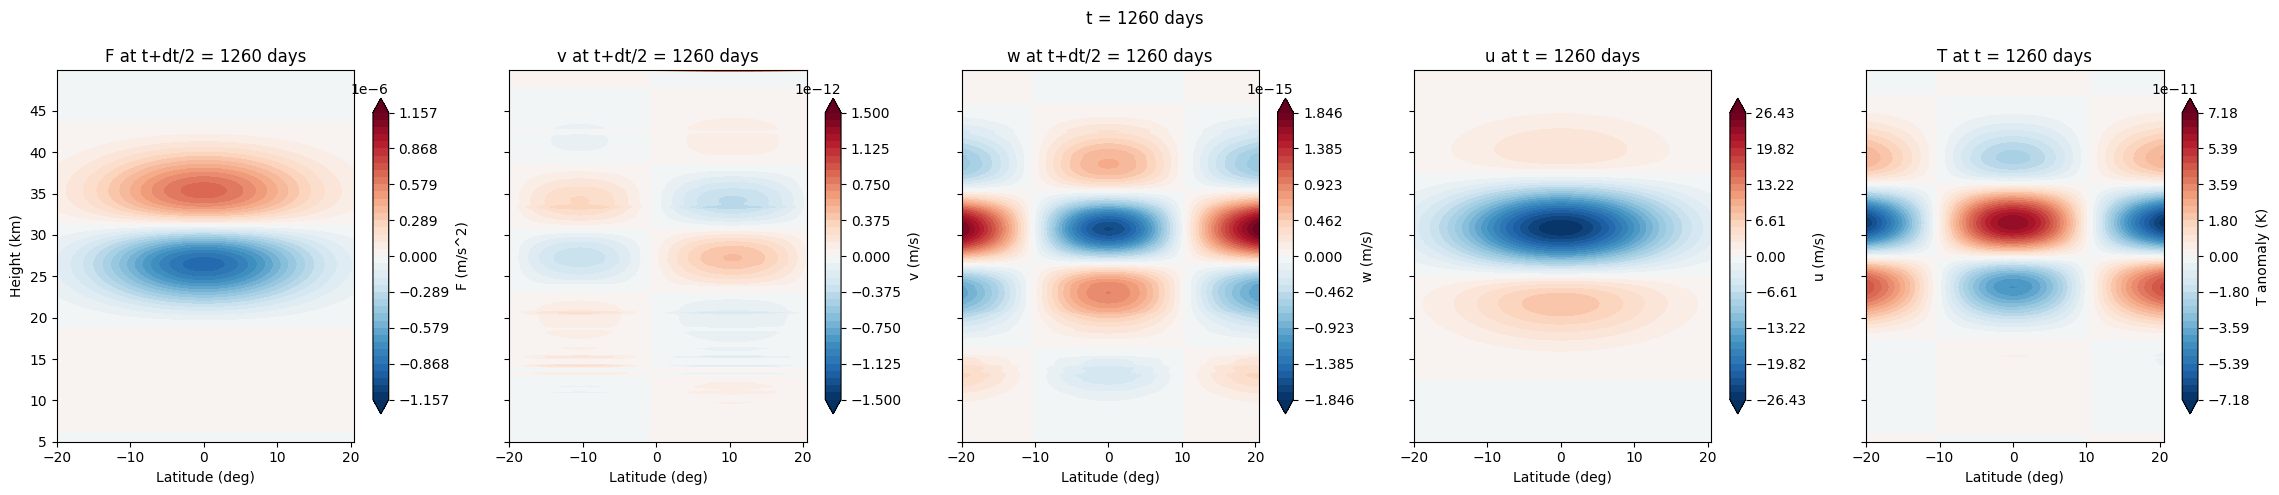

In [29]:
# -- Snapshots of F, v, w, u, and T --------------------------------------------
snapshot_days = [0, 420, 840, 1260]
snapshot_indices = sorted({nearest_time_index(day) for day in snapshot_days})
snapshot_indices = [k for k in snapshot_indices if k < len(F_store)]

for k in snapshot_indices:
    fields = [
        (F_store[k], levels_F, "RdBu_r", "F (m/s^2)", f"F at t+dt/2 = {t_plus_dt2_days[k]:.0f} days"),
        (v_store[k], levels_v, "RdBu_r", "v (m/s)", f"v at t+dt/2 = {t_plus_dt2_days[k]:.0f} days"),
        (w_store[k], levels_w, "RdBu_r", "w (m/s)", f"w at t+dt/2 = {t_plus_dt2_days[k]:.0f} days"),
        (U_store[k], levels_U, "RdBu_r", "u (m/s)", f"u at t = {t_days[k]:.0f} days"),
        (T_store[k], levels_T, "RdBu_r", "T anomaly (K)", f"T at t = {t_days[k]:.0f} days"),
    ]

    fig, axes = plt.subplots(1, 5, figsize=(23, 5), sharey=True)
    for ax, (data, levels, cmap, cbar_label, title) in zip(axes, fields):
        cf = ax.contourf(LAT, Z_km, data, levels=levels, cmap=cmap, extend="both")
        fig.colorbar(cf, ax=ax, label=cbar_label, shrink=0.85)
        ax.set_xlabel("Latitude (deg)")
        ax.set_title(title)

    axes[0].set_ylabel("Height (km)")
    fig.suptitle(f"t = {t_days[k]:.0f} days")
    fig.tight_layout()
    plt.show()


F at t+dt/2: target 0 deg -> plotted grid latitude 0 deg
F at t+dt/2: target 10 deg -> plotted grid latitude 10 deg
F at t+dt/2: target 15 deg -> plotted grid latitude 15 deg


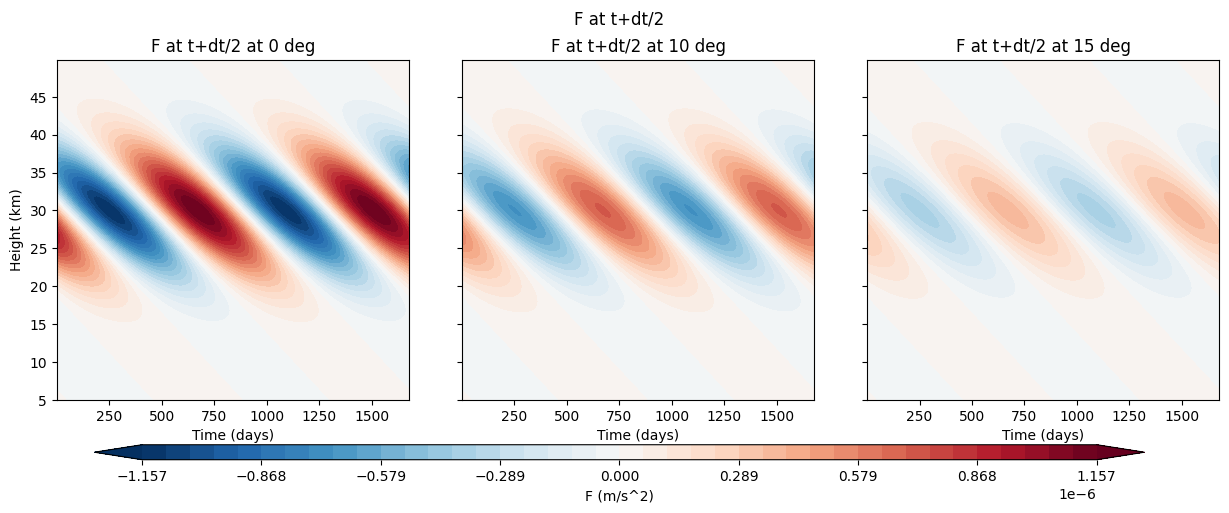

v at t+dt/2: target 0 deg -> plotted grid latitude 0 deg
v at t+dt/2: target 10 deg -> plotted grid latitude 10 deg
v at t+dt/2: target 15 deg -> plotted grid latitude 15 deg


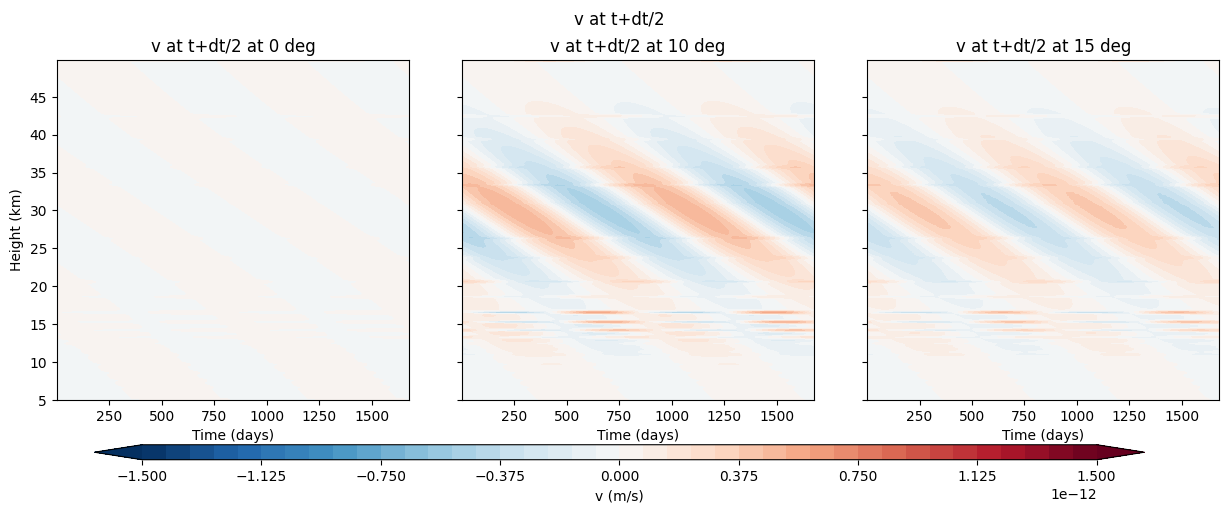

w at t+dt/2: target 0 deg -> plotted grid latitude 0 deg
w at t+dt/2: target 10 deg -> plotted grid latitude 10 deg
w at t+dt/2: target 15 deg -> plotted grid latitude 15 deg


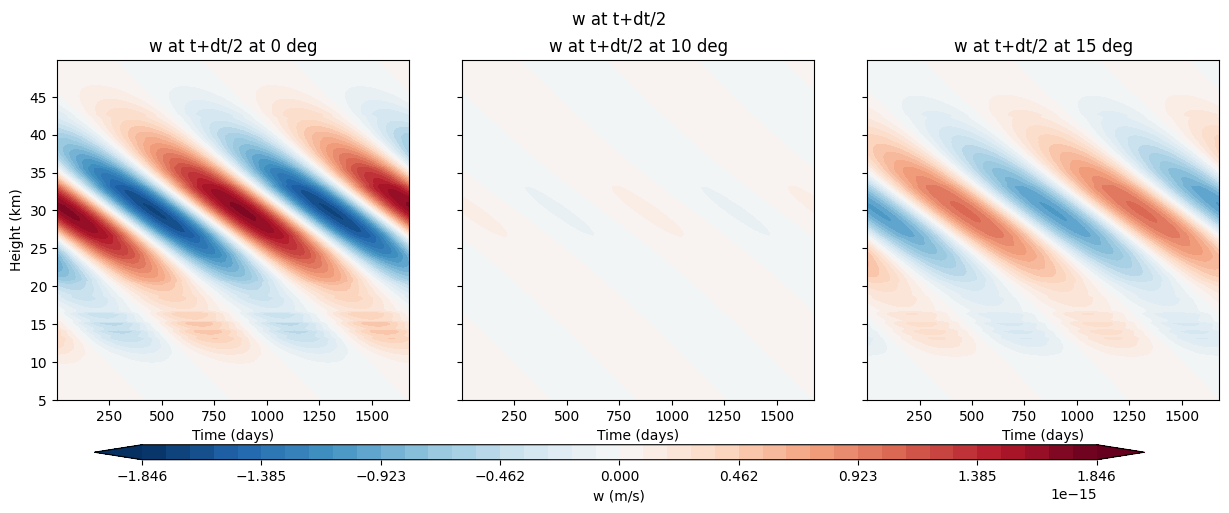

u at t: target 0 deg -> plotted grid latitude 0 deg
u at t: target 10 deg -> plotted grid latitude 10 deg
u at t: target 15 deg -> plotted grid latitude 15 deg


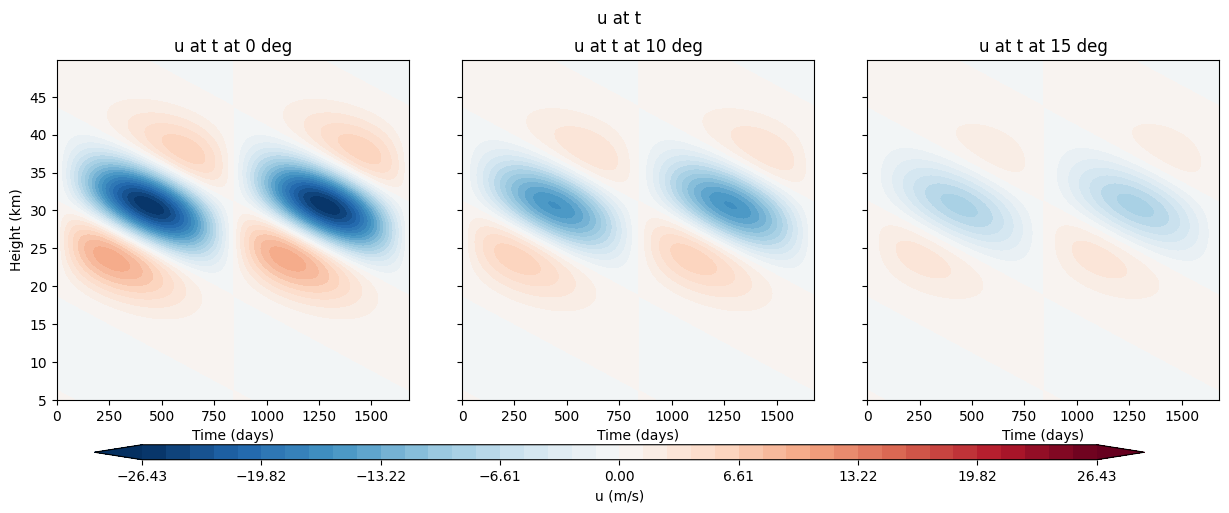

T at t: target 0 deg -> plotted grid latitude 0 deg
T at t: target 10 deg -> plotted grid latitude 10 deg
T at t: target 15 deg -> plotted grid latitude 15 deg


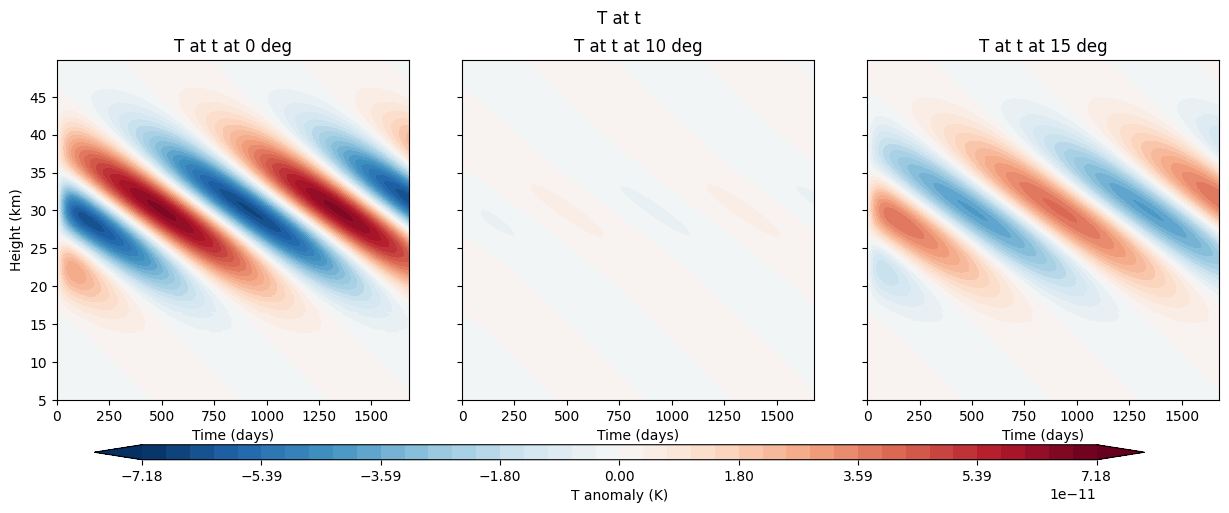

In [30]:
# -- Hovmoller diagrams for F, v, w, u, and T at target latitudes ---------------
def plot_hovmoller(field_name, data, x_days, x_label, levels, cbar_label):
    x_grid, z_grid = np.meshgrid(x_days, z / 1000.0)
    fig, axes = plt.subplots(1, len(target_lat_indices), figsize=(5 * len(target_lat_indices), 5), sharey=True)
    if len(target_lat_indices) == 1:
        axes = [axes]

    for ax, target, iy in zip(axes, target_lats, target_lat_indices):
        hov = data[:, :, iy]
        cf = ax.contourf(x_grid.T, z_grid.T, hov, levels=levels, cmap="RdBu_r", extend="both")
        ax.set_xlabel(x_label)
        ax.set_title(f"{field_name} at {lat[iy]:g} deg")
        print(f"{field_name}: target {target:g} deg -> plotted grid latitude {lat[iy]:g} deg")

    axes[0].set_ylabel("Height (km)")
    cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.03])
    fig.colorbar(cf, cax=cbar_ax, orientation="horizontal", label=cbar_label)
    fig.subplots_adjust(bottom=0.2, wspace=0.15)
    fig.suptitle(field_name)
    plt.show()

plot_hovmoller(
    "F at t+dt/2",
    F_store,
    t_plus_dt2_days,
    "Time (days)",
    levels_F,
    "F (m/s^2)",
)

plot_hovmoller(
    "v at t+dt/2",
    v_store,
    t_plus_dt2_days,
    "Time (days)",
    levels_v,
    "v (m/s)",
)

plot_hovmoller(
    "w at t+dt/2",
    w_store,
    t_plus_dt2_days,
    "Time (days)",
    levels_w,
    "w (m/s)",
)

plot_hovmoller(
    "u at t",
    U_store,
    t_days,
    "Time (days)",
    levels_U,
    "u (m/s)",
)

plot_hovmoller(
    "T at t",
    T_store,
    t_days,
    "Time (days)",
    levels_T,
    "T anomaly (K)",
)


In [19]:
# -- Optional animation: F, v, w, u, and T --------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(24, 5), sharey=True)
plt.subplots_adjust(wspace=0.28)

initial_plots = [
    axes[0].contourf(LAT, Z_km, F_store[0], levels=levels_F, cmap="RdBu_r", extend="both"),
    axes[1].contourf(LAT, Z_km, v_store[0], levels=levels_v, cmap="RdBu_r", extend="both"),
    axes[2].contourf(LAT, Z_km, w_store[0], levels=levels_w, cmap="RdBu_r", extend="both"),
    axes[3].contourf(LAT, Z_km, U_store[0], levels=levels_U, cmap="RdBu_r", extend="both"),
    axes[4].contourf(LAT, Z_km, T_store[0], levels=levels_T, cmap="RdBu_r", extend="both"),
]

for ax, cf, label in zip(axes, initial_plots, ["F (m/s^2)", "v (m/s)", "w (m/s)", "u (m/s)", "T anomaly (K)"]):
    fig.colorbar(cf, ax=ax, label=label, shrink=0.8)
    ax.set_xlabel("Latitude (deg)")

axes[0].set_ylabel("Height (km)")

def update(k):
    for ax in axes:
        ax.clear()

    axes[0].contourf(LAT, Z_km, F_store[k], levels=levels_F, cmap="RdBu_r", extend="both")
    axes[1].contourf(LAT, Z_km, v_store[k], levels=levels_v, cmap="RdBu_r", extend="both")
    axes[2].contourf(LAT, Z_km, w_store[k], levels=levels_w, cmap="RdBu_r", extend="both")
    axes[3].contourf(LAT, Z_km, U_store[k], levels=levels_U, cmap="RdBu_r", extend="both")
    axes[4].contourf(LAT, Z_km, T_store[k], levels=levels_T, cmap="RdBu_r", extend="both")

    axes[0].set_title(f"F at t+dt/2 = {t_plus_dt2_days[k]:.0f} days")
    axes[1].set_title(f"v at t+dt/2 = {t_plus_dt2_days[k]:.0f} days")
    axes[2].set_title(f"w at t+dt/2 = {t_plus_dt2_days[k]:.0f} days")
    axes[3].set_title(f"u at t = {t_days[k]:.0f} days")
    axes[4].set_title(f"T at t = {t_days[k]:.0f} days")

    for ax in axes:
        ax.set_xlabel("Latitude (deg)")
    axes[0].set_ylabel("Height (km)")
    fig.suptitle(f"t = {t_days[k]:.0f} days")
    return axes

update(0)
ani = animation.FuncAnimation(fig, update, frames=len(F_store), interval=100, blit=False)
plt.close()
HTML(ani.to_jshtml())

# To save the animation explicitly, uncomment this line:
# ani.save("qbo_animation.gif", writer="pillow", fps=10)


Exception ignored in: <function WeakSet.__init__.<locals>._remove at 0x16ba12160>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.13/3.13.3_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/_weakrefset.py", line 39, in _remove
    def _remove(item, selfref=ref(self)):
KeyboardInterrupt: 
Animation size has reached 21341184 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


KeyboardInterrupt: 